# Fuzzy MCDA Methods under VISTA

This notebook explores how fuzzy MCDA ranking methods behave under the VISTA visualization framework.

VISTA sweeps a test alternative across a 2-D criteria grid and classifies each point by its
relation (Better / Worse / Indifferent / Incomparable) to a fixed reference alternative.
For evaluating fuzzy ranking methods, one can *fuzzify each crisp grid point into a triangular fuzzy number
parametrized by `spread` (support half-width) and `skew` (asymmetry).

We will use this approach to:
1. **Validate** fuzzy wrappers against their crisp counterparts (spread → 0).
2. **Visualize** how increasing fuzzification uncertainty reshapes decision boundaries.
3. **Compare** four fuzzy methods side-by-side: TOPSIS, VIKOR, MOORA, WASPAS.

## 1. Introduction & Setup

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

from mcda_vista import (
    generate_vista,
    plot_vista,
    plot_vista_grid,
    plot_vista_comparison,
    Relation,
)
from mcda_vista.fuzzy_utils import (
    fuzzy_topsis,
    fuzzy_vikor,
    fuzzy_moora,
    fuzzy_waspas,
)

## 2. Baseline: Crisp TOPSIS vs Fuzzy TOPSIS (spread = 0)

When `spread=0`, every triangular fuzzy number degenerates to a crisp value, so the fuzzy
wrapper should reproduce the crisp TOPSIS result exactly. This serves as a sanity check
for the fuzzification pipeline.

In [2]:
result_crisp = generate_vista("topsis", resolution=51, delta=0.10, progress=False)
result_fuzzy0 = generate_vista(fuzzy_topsis, resolution=51, spread=0.0, delta=0.10, progress=False)

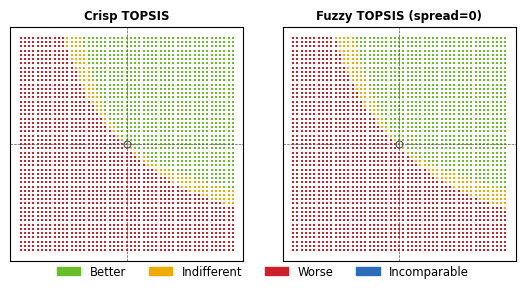

In [3]:
result_crisp.method_name = "Crisp TOPSIS"
result_fuzzy0.method_name = "Fuzzy TOPSIS (spread=0)"

plot_vista_comparison([result_crisp, result_fuzzy0])
plt.show()

## 3. Effect of Spread on Fuzzy TOPSIS

We now sweep the `spread` parameter from 0 (crisp) to 0.30 (wide uncertainty) and observe
how the VISTA decision boundaries evolve.

In [5]:
spreads = [0.0, 0.10, 0.20, 0.30, 0.40, 0.50]

spread_results = []
for s in spreads:
    r = generate_vista(fuzzy_topsis, resolution=51, spread=s, delta=0.10, progress=False)
    r.method_name = f"spread={s}"
    spread_results.append(r)

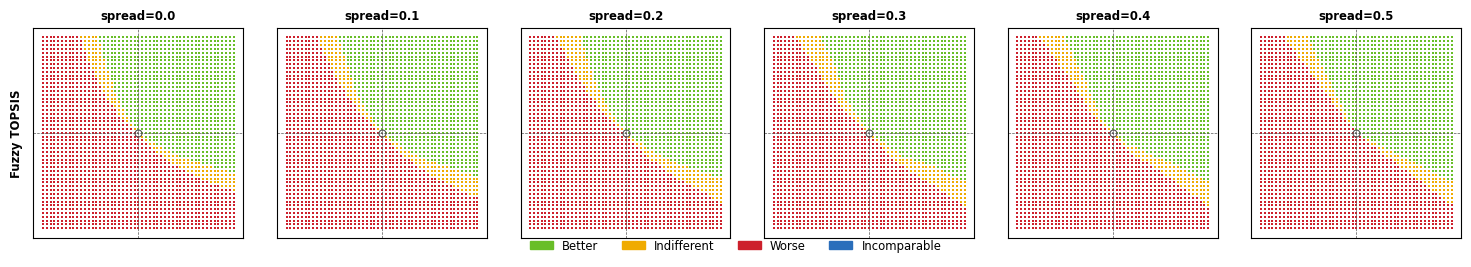

In [7]:
plot_vista_grid(
    [spread_results],
    row_labels=["Fuzzy TOPSIS"],
    col_labels=[f"spread={s}" for s in spreads],
    point_size=3
)
plt.show()

## 4. Effect of Skew (Asymmetric Fuzzy Numbers)

Fixing `spread=0.30`, we vary `skew` in {−1.0, −0.5, 0.0, 0.5, 1.0}. Negative skew shifts the
triangle support to the left (pessimistic), positive skew to the right (optimistic).

In [8]:
skews = [-1.0, -0.5, 0.0, 0.5, 1.0]

skew_results = []
for sk in skews:
    r = generate_vista(
        fuzzy_topsis, resolution=51, spread=0.30, skew=sk, delta=0.10, progress=False
    )
    r.method_name = f"skew={sk}"
    skew_results.append(r)

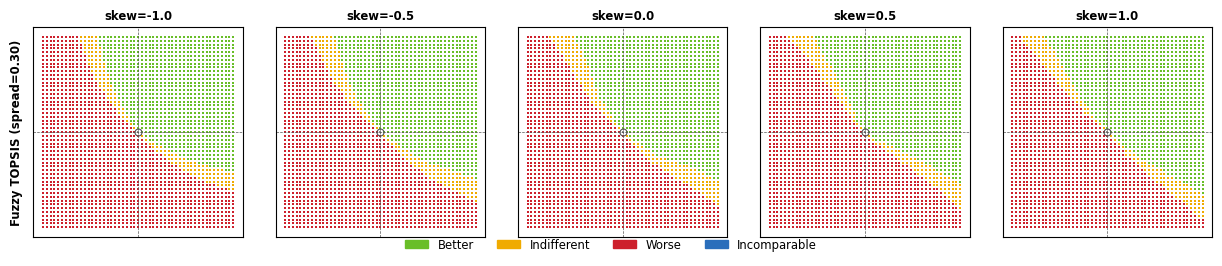

In [9]:
plot_vista_grid(
    [skew_results],
    row_labels=["Fuzzy TOPSIS (spread=0.30)"],
    col_labels=[f"skew={sk}" for sk in skews],
)
plt.show()

## 5. Cross-Method Comparison

We compare four fuzzy wrappers at `spread=0.10`, `delta=0.10`.

> **Note:** Fuzzy VIKOR may produce a few ERROR points at degenerate grid positions
> where the 2-alternative normalization breaks down — this is expected.

In [10]:
methods = [
    (fuzzy_topsis, "Fuzzy TOPSIS"),
    (fuzzy_vikor, "Fuzzy VIKOR"),
    (fuzzy_moora, "Fuzzy MOORA"),
    (fuzzy_waspas, "Fuzzy WASPAS"),
]

method_results = []
for fn, name in methods:
    r = generate_vista(fn, resolution=51, spread=0.30, delta=0.10, progress=False)
    r.method_name = name
    method_results.append(r)

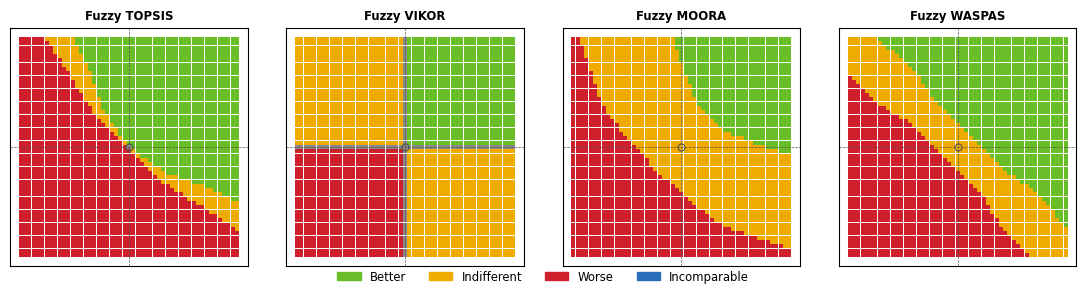

In [12]:
plot_vista_comparison(method_results, ncols=4, point_size=5)
plt.show()

## 6. Summary

The table below counts the number of grid points classified into each relation category
across the key configurations explored above.

In [13]:
# Collect all results we want to summarise
summary_results = [
    result_crisp,
    result_fuzzy0,
    *spread_results,
    *skew_results,
    *method_results,
]

# Relation labels in display order
relation_labels = ["BETTER", "WORSE", "INDIFFERENT", "INCOMPARABLE", "ERROR"]

# Header
header = f"{'Configuration':<35s}" + "".join(f"{lbl:>15s}" for lbl in relation_labels)
print(header)
print("-" * len(header))

for r in summary_results:
    unique, counts = np.unique(r.relations, return_counts=True)
    count_map = dict(zip(unique, counts))
    row = f"{r.method_name:<35s}"
    for lbl in relation_labels:
        rel = getattr(Relation, lbl, None)
        row += f"{count_map.get(rel, 0):>15d}"
    print(row)

Configuration                               BETTER          WORSE    INDIFFERENT   INCOMPARABLE          ERROR
--------------------------------------------------------------------------------------------------------------
Crisp TOPSIS                                   983           1477            140              0              1
Fuzzy TOPSIS (spread=0)                        971           1467            162              0              1
spread=0.0                                     971           1467            162              0              1
spread=0.1                                     999           1429            172              0              1
spread=0.2                                    1007           1407            186              0              1
spread=0.3                                    1011           1395            194              0              1
spread=0.4                                     999           1419            182              0              1
s